In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ตั้งค่าสไตล์สำหรับกราฟ
sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = (
    'sans-serif'  # ใช้ฟอนต์มาตรฐานสำหรับแสดงผลกราฟให้สวยงาม
)

# ==========================================
# LAB 1: Dataset Exploration
# ==========================================
print('=' * 50)
print('LAB 1: DATASET EXPLORATION')
print('=' * 50)

# 1. Load Dataset
df = pd.read_csv('student_performance_lab2.csv')
print('1. โหลดข้อมูลสำเร็จ ตัวอย่างข้อมูล 5 แถวแรก:')
print(df.head())

# 2. Display Shape
print('\n2. รูปร่างของข้อมูล (Shape):')
print(f'จำนวนแถว: {df.shape[0]}, จำนวนคอลัมน์: {df.shape[1]}')

# 3. Display Data Types
print('\n3. ชนิดของข้อมูลในแต่ละคอลัมน์ (Data Types):')
print(df.dtypes)

# 4. Display Summary Statistics
print('\n4. สถิติเชิงพรรณนา (Summary Statistics):')
print(df.describe(include='all'))

# 5. Display Missing Values
print('\n5. จำนวนข้อมูลที่สูญหาย (Missing Values):')
print(df.isnull().sum())

# 6. Display Duplicate Records
print('\n6. ตรวจสอบข้อมูลซ้ำ (Duplicate Records):')
duplicates = df[df.duplicated(keep=False)]
print(f'พบข้อมูลซ้ำทั้งหมด: {df.duplicated().sum()} แถว')
print(duplicates)

# 7. Display Class Distribution
print('\n7. การกระจายตัวของคลาสคำตอบ (Class Distribution - Passed):')
print(df['Passed'].value_counts())
print('\nคิดเป็นสัดส่วนร้อยละ (%):')
print(df['Passed'].value_counts(normalize=True) * 100)

LAB 1: DATASET EXPLORATION
1. โหลดข้อมูลสำเร็จ ตัวอย่างข้อมูล 5 แถวแรก:
  Student_ID   Age  Study_Hours  Score Education_Level Department Passed
0       S001  20.0         12.5   75.0     High School         CS    Yes
1       S002  21.0         15.0   82.5        Bachelor         IT    Yes
2       S003  -5.0          8.0   50.0     High School         SE     No
3       S004  22.0         20.0   95.0          Master         DS    Yes
4       S005  20.0         10.0   68.0        Bachelor         CS    Yes

2. รูปร่างของข้อมูล (Shape):
จำนวนแถว: 20, จำนวนคอลัมน์: 7

3. ชนิดของข้อมูลในแต่ละคอลัมน์ (Data Types):
Student_ID             str
Age                float64
Study_Hours        float64
Score              float64
Education_Level        str
Department             str
Passed                 str
dtype: object

4. สถิติเชิงพรรณนา (Summary Statistics):
       Student_ID         Age  Study_Hours      Score Education_Level  \
count          20   18.000000    18.000000  18.000000             


LAB 2: DATA VISUALIZATION


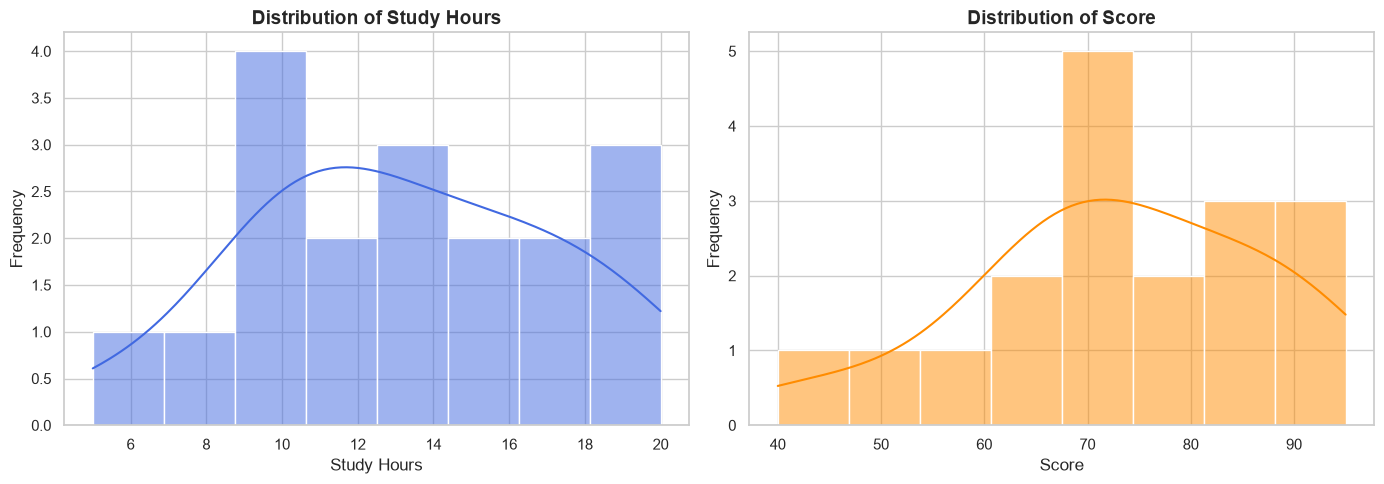

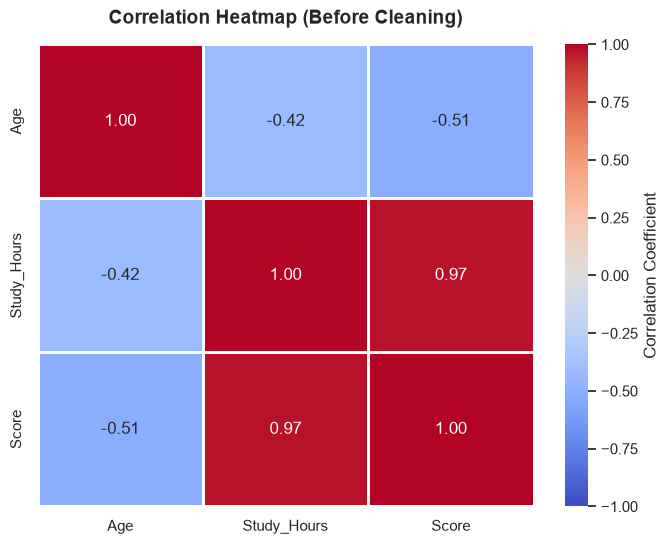

In [5]:
# ==========================================
# LAB 2: Data Visualization 
# ==========================================
print('\n' + '=' * 50)
print('LAB 2: DATA VISUALIZATION')
print('=' * 50)

# 1. Histogram (แสดงการกระจายตัวของข้อมูลตัวเลข Study_Hours และ Score)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# กราฟที่ 1: Histogram ของชั่วโมงการอ่านหนังสือ
sns.histplot(
    df['Study_Hours'].dropna(),
    kde=True,
    color='royalblue',
    bins=8,
    ax=axes[0],
)
axes[0].set_title(
    'Distribution of Study Hours', fontsize=14, fontweight='bold'
)
axes[0].set_xlabel('Study Hours', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# กราฟที่ 2: Histogram ของคะแนนสอบ
sns.histplot(
    df['Score'].dropna(), kde=True, color='darkorange', bins=8, ax=axes[1]
)
axes[1].set_title('Distribution of Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Score', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

# 2. Correlation Heatmap (หาความสัมพันธ์ระหว่างตัวแปรเชิงตัวเลข)
# หมายเหตุ: เลือกเฉพาะคอลัมน์ที่เป็น float/int (ในขั้นตอนนี้ Age ยังเป็น Object จึงยังไม่ถูกนำมาคำนวณ)
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=1,
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Correlation Coefficient'},
)
plt.title(
    'Correlation Heatmap (Before Cleaning)', fontsize=14, fontweight='bold', pad=15
)
plt.show()


PART 3: DATA CLEANING
1. ลบข้อมูลซ้ำเรียบร้อย ข้อมูลคงเหลือ: 19 แถว

2. แก้ไขสิ่งผิดปกติและแปลงชนิดข้อมูลคอลัมน์ Age เรียบร้อยแล้ว
   ข้อมูล Age ที่ผ่านการคัดกรอง: [20. 21. nan 22. 20. nan 23. nan 21. 22. nan 20. 19. 21. 22. 20. 23. 21.
 22.]

3. เปรียบเทียบการเติมค่าว่างด้วย Mean และ Median (คอลัมน์ Study_Hours):
   -> ค่าเฉลี่ย (Mean): 13.35
   -> ค่ามัธยฐาน (Median): 13.00

ตรวจสอบจำนวนค่าว่างหลังทำ Data Cleaning ทั้งหมด:
Student_ID         0
Age                0
Study_Hours        0
Score              0
Education_Level    0
Department         0
Passed             0
dtype: int64


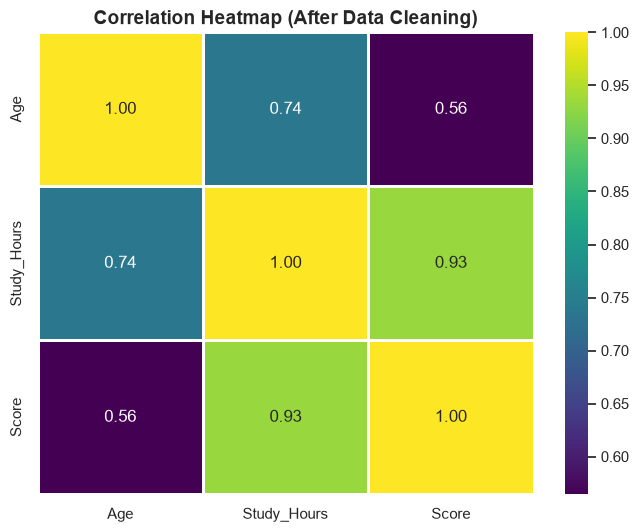

In [6]:
# ==========================================
# PART 3: Data Cleaning
# ==========================================
print('\n' + '=' * 50)
print('PART 3: DATA CLEANING')
print('=' * 50)

# สร้างสำเนาข้อมูลเพื่อทำการทำความสะอาด
df_clean = df.copy()

# 1. Duplicate Removal (ลบข้อมูลซ้ำ)
df_clean.drop_duplicates(inplace=True)
print(f'1. ลบข้อมูลซ้ำเรียบร้อย ข้อมูลคงเหลือ: {df_clean.shape[0]} แถว')

# 2. Incorrect Data Correction & Data Type Conversion
# ตรวจพบ: คอลัมน์ Age มีข้อความเว้นวรรค (' 21 '), ค่าติดลบ (-5) และอายุเกินจริง (200)
# 2.1 ตัดสเปซ และแปลงจาก string/object เป็น numeric (ค่าที่แปลงไม่ได้จะกลายเป็น NaN)
df_clean['Age'] = pd.to_numeric(
    df_clean['Age'].astype(str).str.strip(), errors='coerce'
)

# 2.2 เปลี่ยนค่าที่เป็นไปไม่ได้ (อายุ <= 0 หรือ > 100) ให้เป็น NaN เพื่อรอ Impute
df_clean.loc[(df_clean['Age'] <= 0) | (df_clean['Age'] > 100), 'Age'] = np.nan
print('\n2. แก้ไขสิ่งผิดปกติและแปลงชนิดข้อมูลคอลัมน์ Age เรียบร้อยแล้ว')
print('   ข้อมูล Age ที่ผ่านการคัดกรอง:', df_clean['Age'].values)

# 3. Missing Value Handling & Compare Mean vs Median
print('\n3. เปรียบเทียบการเติมค่าว่างด้วย Mean และ Median (คอลัมน์ Study_Hours):')
mean_val = df_clean['Study_Hours'].mean()
median_val = df_clean['Study_Hours'].median()
print(f'   -> ค่าเฉลี่ย (Mean): {mean_val:.2f}')
print(f'   -> ค่ามัธยฐาน (Median): {median_val:.2f}')

# ดำเนินการแทนที่ค่าว่าง (Imputation):
# - Age ใช้ Median เพราะทนทานต่อ Outlier
# - Study_Hours และ Score ใช้ Mean
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Study_Hours'] = df_clean['Study_Hours'].fillna(
    df_clean['Study_Hours'].mean()
)
df_clean['Score'] = df_clean['Score'].fillna(df_clean['Score'].mean())

print('\nตรวจสอบจำนวนค่าว่างหลังทำ Data Cleaning ทั้งหมด:')
print(df_clean.isnull().sum())

# (โบนัส) แสดง Heatmap อีกครั้งหลังทำความสะอาดข้อมูลเรียบร้อย (มี Age เพิ่มเข้ามาแล้ว)
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_clean.select_dtypes(include=[np.number]).corr(),
    annot=True,
    cmap='viridis',
    fmt='.2f',
    linewidths=1,
)
plt.title('Correlation Heatmap (After Data Cleaning)', fontsize=14, fontweight='bold')
plt.show()

In [7]:
# ==========================================
# PART 4: Feature Engineering
# ==========================================
print('\n' + '=' * 50)
print('PART 4: FEATURE ENGINEERING')
print('=' * 50)

from sklearn.preprocessing import LabelEncoder

# 1. Label Encoding (เหมาะสำหรับข้อมูลที่มีลำดับชั้น เช่น ระดับการศึกษา)
# High School -> 1, Bachelor -> 0, Master -> 2 (ลำดับอิงตามตัวอักษรตั้งต้น หรือเราสามารถ map เองได้)
le = LabelEncoder()
df_clean['Education_Encoded'] = le.fit_transform(df_clean['Education_Level'])

print('1. ผลการทำ Label Encoding (คอลัมน์ Education_Level):')
for class_name, encoded_val in zip(
    le.classes_, le.transform(le.classes_)
):
  print(f'   - {class_name} => {encoded_val}')

# 2. One-Hot Encoding (เหมาะสำหรับข้อมูลเชิงนามบัญญัติที่ไม่มีลำดับชั้น เช่น ภาควิชา Department)
# ใช้ pd.get_dummies แปลงคอลัมน์ Department ให้เป็นคอลัมน์ย่อย (0 หรือ 1)
df_final = pd.get_dummies(
    df_clean, columns=['Department'], prefix='Dept', dtype=int
)

print('\n2. ผลลัพธ์สุดท้ายหลังทำ One-Hot Encoding (ตัวอย่าง 5 แถวแรก):')
display_cols = [
    'Student_ID',
    'Education_Level',
    'Education_Encoded',
] + [col for col in df_final.columns if 'Dept_' in col]
print(df_final[display_cols].head())

print('\n--- สรุปรูปร่างของข้อมูลเตรียมพร้อมสำหรับนำไปเข้าโมเดล Machine Learning ---')
print(f'Final Shape: {df_final.shape}')


PART 4: FEATURE ENGINEERING
1. ผลการทำ Label Encoding (คอลัมน์ Education_Level):
   - Bachelor => 0
   - High School => 1
   - Master => 2

2. ผลลัพธ์สุดท้ายหลังทำ One-Hot Encoding (ตัวอย่าง 5 แถวแรก):
  Student_ID Education_Level  Education_Encoded  Dept_CS  Dept_DS  Dept_IT  \
0       S001     High School                  1        1        0        0   
1       S002        Bachelor                  0        0        0        1   
2       S003     High School                  1        0        0        0   
3       S004          Master                  2        0        1        0   
4       S005        Bachelor                  0        1        0        0   

   Dept_SE  
0        0  
1        0  
2        1  
3        0  
4        0  

--- สรุปรูปร่างของข้อมูลเตรียมพร้อมสำหรับนำไปเข้าโมเดล Machine Learning ---
Final Shape: (19, 11)
